In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import cv2
from quiescence_analysis import load_tiff


%load_ext autoreload
%autoreload 2




ImportError: cannot import name 'load_tiff' from 'quiescence_analysis' (C:\Users\itamar.lev\Anaconda3\envs\wb_process\lib\site-packages\quiescence_analysis\__init__.py)

### load binarized image ###

In [11]:
img_path = r'C:\Users\jfran\OneDrive\Dokumente\GitHub\quiescence_analysis\bin_worm_example.tiff'


In [12]:
img = load_tiff(img_path)

In [27]:
idx = 250
frame = img[:,:,idx]
next_frame = img[:,:,idx+3]

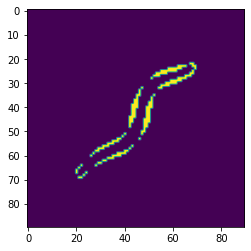

In [28]:
plt.imshow(np.abs(next_frame-frame))

### investigate contours ###

In [29]:
frames_diff = np.abs(next_frame-frame).astype(np.uint8)

contours, hierarchy = cv2.findContours(frames_diff, cv2.RETR_TREE, cv2.CHAIN_APPROX_NONE)[-2:]


area of 0 is: 0.0
area of 1 is: 0.0
area of 2 is: 4.0
area of 3 is: 0.0
area of 4 is: 5.0
area of 5 is: 15.0
area of 6 is: 14.0
area of 7 is: 11.0
area of 8 is: 12.0


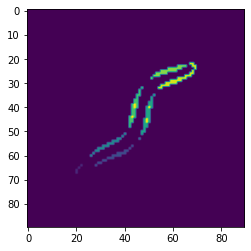

In [30]:
img_diff = frames_diff.copy()

#to draw contours, iterate over contours
for cont_idx in range(len(contours)):
    cont_color = min(cont_idx*30,255)
    cv2.drawContours(img_diff, contours,cont_idx,color=cont_color, thickness=1, hierarchy=hierarchy, maxLevel=1)
    area = cv2.contourArea(contours[cont_idx])
    print("area of",cont_idx,"is:",area)
    plt.imshow(img_diff)


Result - Image


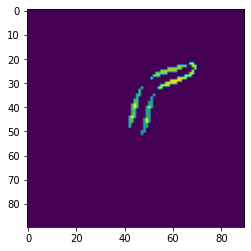

In [33]:
threshold = 6

mask = np.zeros(img_diff.shape[:2], dtype=img_diff.dtype)

for c in contours:
    if cv2.contourArea(c) > threshold:
        x, y, w, h = cv2.boundingRect(c)
        cv2.drawContours(mask, [c], 0, (255), -1)
        
result = cv2.bitwise_and(img_diff,img_diff, mask= mask)

print('Result - Image')
plt.imshow(result)




In [ ]:
### need to write ###
def filter_contours_by_size(contours,size_threshold):
    
    return contours


In [ ]:
### need to write ###
def calculate_pixel_diff(filtered_contours():
    return pixel_diff